In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./datasets/Coleta_Brancas.csv")

In [3]:
df

,Name,Original_Text,Cor,Conclusao
0,Adilson Candido Da Silva,\nExcelentíssimo(a) Senhor(a) Doutor(a) Juiz(a...,Branca,NaN
1,Adilson Candido Da Silva,EXCELENTÍSSIMO SENHOR DOUTOR JUIZ FEDERAL DA ...,Branca,NaN
2,Adilson Candido Da Silva,EXCELENTÍSSIMO SENHOR DOUTOR JUIZ DE DIREITO ...,Branca,NaN
3,Adilson Candido Da Silva,\nFls.: 2\nEXCELENTÍSSIMO SENHOR DOUTOR JUIZ D...,Branca,GANHO
4,Adilson Candido Da Silva,EXMO. SR. DR. JUIZ DE DIREITO DA 7º VARA CÍVE...,Branca,PERDIDO
...,...,...,...,...
395,Renata Nascimento De Freitas,EXCELENTÍSSIMO SENHOR DOUTOR JUIZ DE DIREITO ...,Branca,NaN
396,Renata Nascimento De Freitas,DECISÃO Processo Digital n°: 1002962-86.2016....,Branca,NaN
397,Renata Nascimento De Freitas,EXMO. SR. DR. JUIZ DE DIREITO DA 12a VARA CÍV...,Branca,AMBIGUO
398,Renata Nascimento De Freitas,EXMA. SRA. JUÍZA DE DIREITO DA QUINTA VARA CR...,Branca,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           400 non-null    object
 1   Original_Text  400 non-null    object
 2   Cor            400 non-null    object
 3   Conclusao      119 non-null    object
dtypes: object(4)
memory usage: 12.6+ KB


In [5]:
situacao = df["Conclusao"].value_counts().reset_index()

In [6]:
situacao

,Conclusao,count
0,PERDIDO,46
1,GANHO,41
2,AMBIGUO,32


In [7]:
situacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Conclusao  3 non-null      object
 1   count      3 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 180.0+ bytes


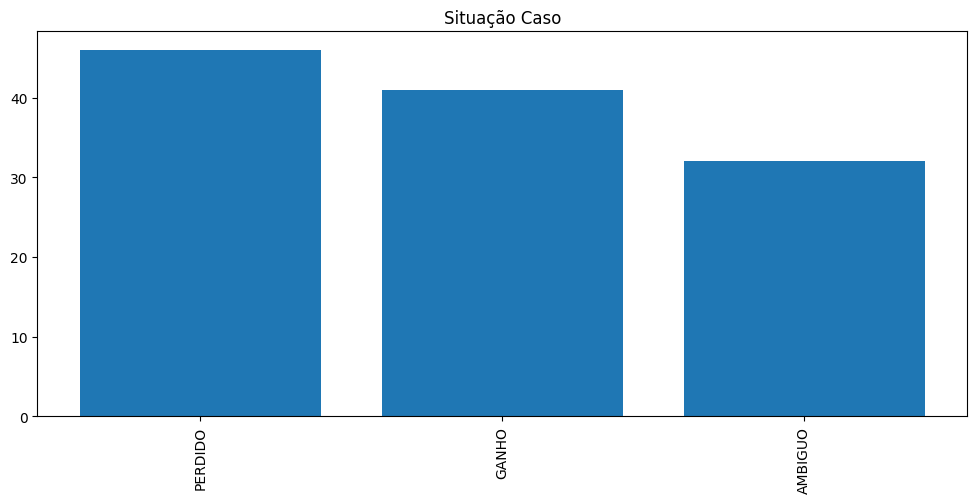

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.bar(situacao["Conclusao"], height=situacao["count"],)
plt.xticks(rotation=90)
# plt.bar()
ax.set_title("Situação Caso")
plt.show()

In [9]:
from nltk.stem import PorterStemmer
import nltk
from nltk.corpus import stopwords

# stopwords = nltk.download('stopwords')
stemmer = PorterStemmer()

## TF - IDF


In [10]:
df = df.dropna(subset="Conclusao")

In [11]:

from sklearn.feature_extraction.text import TfidfVectorizer

tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,2) )
X = tf_idf.fit_transform(df["Original_Text"])
vocab = tf_idf.get_feature_names_out()

In [12]:
vocab

array(['00', '00 00', '00 000', ..., 'šwpàfteš _c', 'šé', 'šé óz'],
      dtype=object)

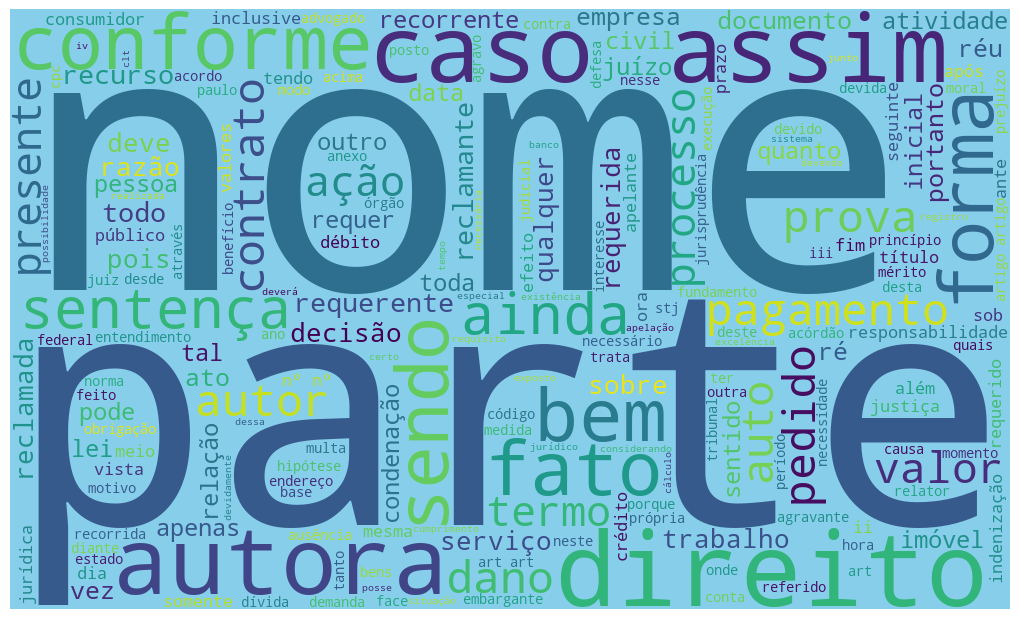

In [13]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud
vocab = ' '.join(vocab)

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='skyblue',
    min_font_size=10).generate(vocab)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [15]:
X

<119x133839 sparse matrix of type '<class 'numpy.float64'>'
	with 304143 stored elements in Compressed Sparse Row format>

In [16]:
df["Conclusao"]

3        GANHO
4      PERDIDO
7        GANHO
8        GANHO
11     AMBIGUO
        ...   
392    PERDIDO
393    PERDIDO
394    PERDIDO
397    AMBIGUO
399      GANHO
Name: Conclusao, Length: 119, dtype: object

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Conclusao"] = le.fit_transform(df["Conclusao"])

C:\Users\alexa\AppData\Local\Temp\ipykernel_14536\3074434007.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Conclusao"] = le.fit_transform(df["Conclusao"])


In [18]:
df["Conclusao"]

3      1
4      2
7      1
8      1
11     0
      ..
392    2
393    2
394    2
397    0
399    1
Name: Conclusao, Length: 119, dtype: int32

In [19]:
from sklearn.decomposition import PCA, TruncatedSVD

pca = TruncatedSVD(n_components=3)

In [20]:
# Fit the PCA model and transform the data
X_pca = pca.fit_transform(X)

# Create a DataFrame for visualization purposes
df_pca = pd.DataFrame(data=X_pca, columns=['Original_Text','Cor', "Conclusao"])
df_pca = df_pca.dropna(subset=["Conclusao"])



In [21]:
y = df["Conclusao"].reset_index(drop=True)

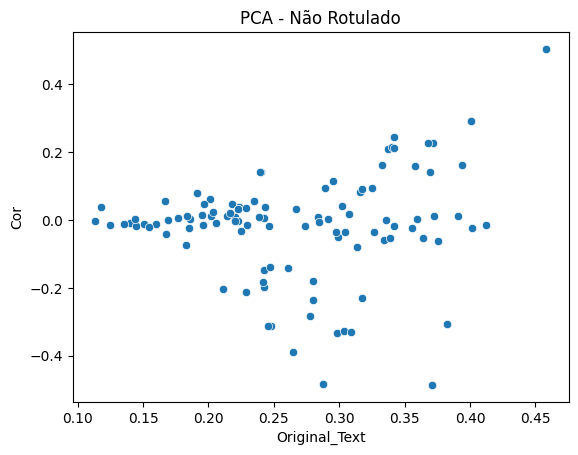

In [22]:



# Visualize the transformed data
sns.scatterplot(x='Original_Text', y="Cor", data=df_pca)
plt.title('PCA - Não Rotulado')
plt.show()

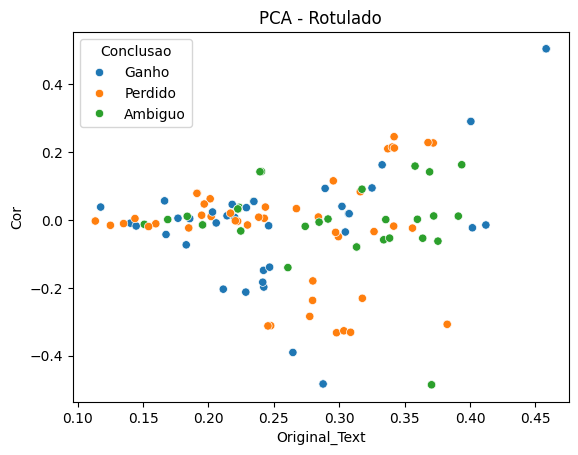

In [23]:
y_map = {0: 'Ambiguo', 1: "Ganho", 2: "Perdido"}


y = y.map(y_map)


df_pca["Conclusao"] = y

# Visualize the transformed data

sns.scatterplot(x='Original_Text', y="Cor", hue="Conclusao", data=df_pca)
plt.title('PCA - Rotulado')
plt.show()

# Treinar Modelo


In [24]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [25]:
X_train

<95x133839 sparse matrix of type '<class 'numpy.float64'>'
	with 245210 stored elements in Compressed Sparse Row format>

In [26]:
# Creating a function to display model results
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
                                "Ambiguo", "Ganho", "Perdido"])
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

# Logistic Regression


In [27]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression  # Replace with your model

# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = LogisticRegression(
    random_state=42, max_iter=1000, solver="lbfgs", penalty="l2", C=1, tol=0.0001)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.45833333 0.625      0.625      0.70833333 0.43478261]
Mean F1 Score: 0.5702898550724638


Classification Report for Data Test
              precision    recall  f1-score   support

     Ambiguo       1.00      0.43      0.60         7
       Ganho       0.50      0.20      0.29        10
     Perdido       0.35      0.86      0.50         7

    accuracy                           0.46        24
   macro avg       0.62      0.50      0.46        24
weighted avg       0.60      0.46      0.44        24



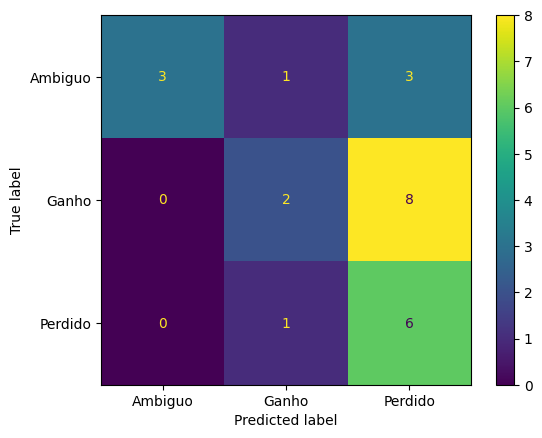

In [28]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

# SGD Classifier


In [29]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier  # Replace with your model

# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = SGDClassifier(random_state=42, alpha=0.0001, )

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.58333333 0.5        0.54166667 0.875      0.56521739]
Mean F1 Score: 0.6130434782608696


Classification Report for Data Test
              precision    recall  f1-score   support

     Ambiguo       0.67      0.57      0.62         7
       Ganho       0.57      0.40      0.47        10
     Perdido       0.45      0.71      0.56         7

    accuracy                           0.54        24
   macro avg       0.56      0.56      0.55        24
weighted avg       0.57      0.54      0.54        24



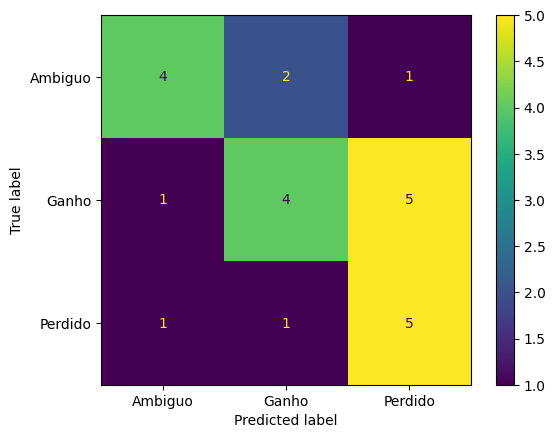

In [30]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluation_parametrics("Machine Learning - SGD", y_test, y_pred)

# KNeighbors Classifier


In [31]:

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
# You can adjust the number of neighbors
model = KNeighborsClassifier(
    n_neighbors=1, weights="uniform", algorithm="brute", leaf_size=30, p=2)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.5        0.54166667 0.54166667 0.83333333 0.56521739]
Mean F1 Score: 0.5963768115942029


Classification Report for Data Test
              precision    recall  f1-score   support

     Ambiguo       0.50      0.57      0.53         7
       Ganho       0.50      0.40      0.44        10
     Perdido       0.50      0.57      0.53         7

    accuracy                           0.50        24
   macro avg       0.50      0.51      0.50        24
weighted avg       0.50      0.50      0.50        24



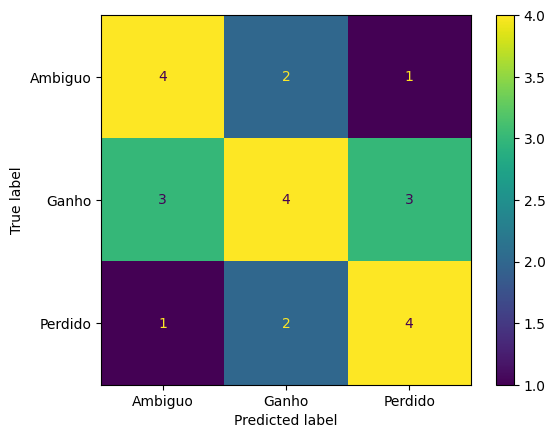

In [32]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluation_parametrics("Machine Learning - KNN", y_test, y_pred)

# SVC


In [33]:

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC

K = 5

kf = KFold(n_splits=K, shuffle=True, random_state=42)


model = LinearSVC(penalty="l2", loss='squared_hinge',
                  tol=0.000001, C=10, multi_class='ovr', dual=True)


cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.54166667 0.5        0.58333333 0.79166667 0.52173913]
Mean F1 Score: 0.5876811594202899


Classification Report for Data Test
              precision    recall  f1-score   support

     Ambiguo       0.75      0.43      0.55         7
       Ganho       0.57      0.40      0.47        10
     Perdido       0.46      0.86      0.60         7

    accuracy                           0.54        24
   macro avg       0.59      0.56      0.54        24
weighted avg       0.59      0.54      0.53        24



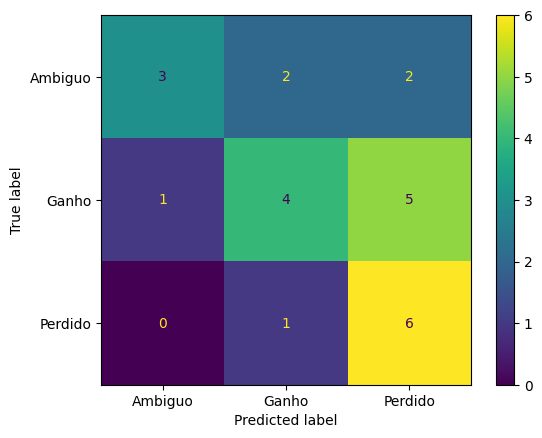

In [34]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest


In [35]:

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = RandomForestClassifier(
    n_estimators=100, criterion='log_loss', max_depth=None, random_state=42)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.5        0.66666667 0.83333333 0.83333333 0.60869565]
Mean F1 Score: 0.6884057971014493


Classification Report for Data Test
              precision    recall  f1-score   support

     Ambiguo       1.00      0.57      0.73         7
       Ganho       1.00      0.30      0.46        10
     Perdido       0.41      1.00      0.58         7

    accuracy                           0.58        24
   macro avg       0.80      0.62      0.59        24
weighted avg       0.83      0.58      0.57        24



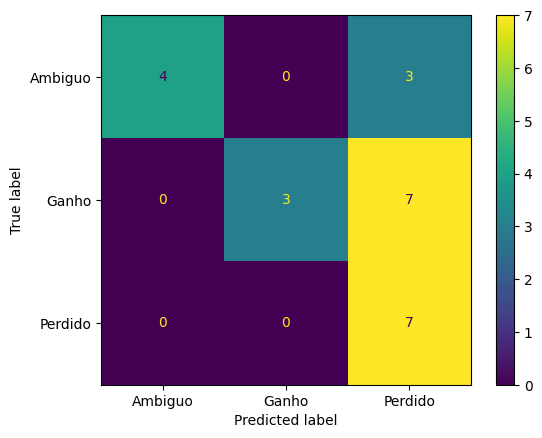

In [36]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

# Decision Tree


Cross-Validation Results: [0.5        0.70833333 0.66666667 0.70833333 0.69565217]
Mean F1 Score: 0.6557971014492754


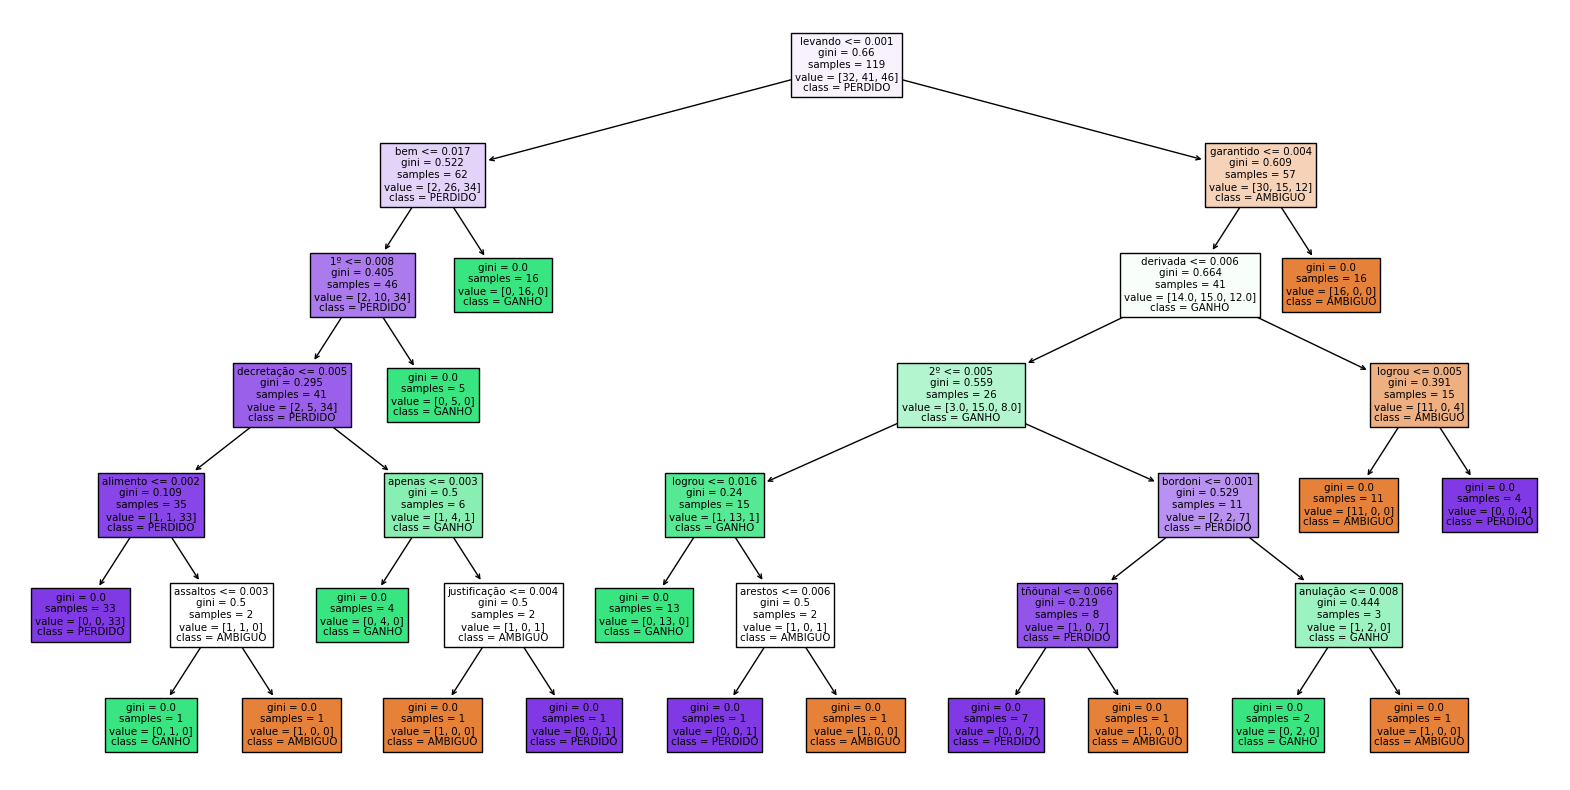

In [37]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Create the decision tree classifier
model = DecisionTreeClassifier(max_leaf_nodes=50, random_state=42)

# Use cross_val_score to perform K-Fold cross-validation
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')

# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

# Fit the decision tree classifier on the entire dataset
model.fit(X, y)

# Plot the decision tree
plt.figure(figsize=(20, 10))  # Adjust the figure size as needed
plot_tree(model, feature_names=vocab.split() ,class_names=["AMBIGUO", "GANHO", "PERDIDO"], filled=True)

plt.show()
